#**Model_Training**

In [ ]:
!pip install xgboost # Install the xgboost package

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
tree_model = DecisionTreeClassifier(max_depth=7, random_state = 42)

In [ ]:
tree_model.fit(train_X, train_targets)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [ ]:
val_preds = tree_model.predict(val_X)
accuracy_score(val_targets, val_preds)

0.8429574603911555

In [ ]:
score = cross_val_score(tree_model, val_X, val_targets, cv=5, scoring='accuracy').mean()

In [ ]:
score

0.7477838442707841

In [ ]:
test_preds = tree_model.predict(test_X)
accuracy_score(test_targets, test_preds)

0.8313313313313313

In [ ]:
score_1 = cross_val_score(tree_model, test_X, test_targets, cv=5, scoring='accuracy').mean()

In [ ]:
score_1

0.8009925200581259

In [ ]:
val_targets.value_counts() / len(val_targets)

,count
RainTomorrow,
No,0.788289
Yes,0.211711


# **Tree_Plot**

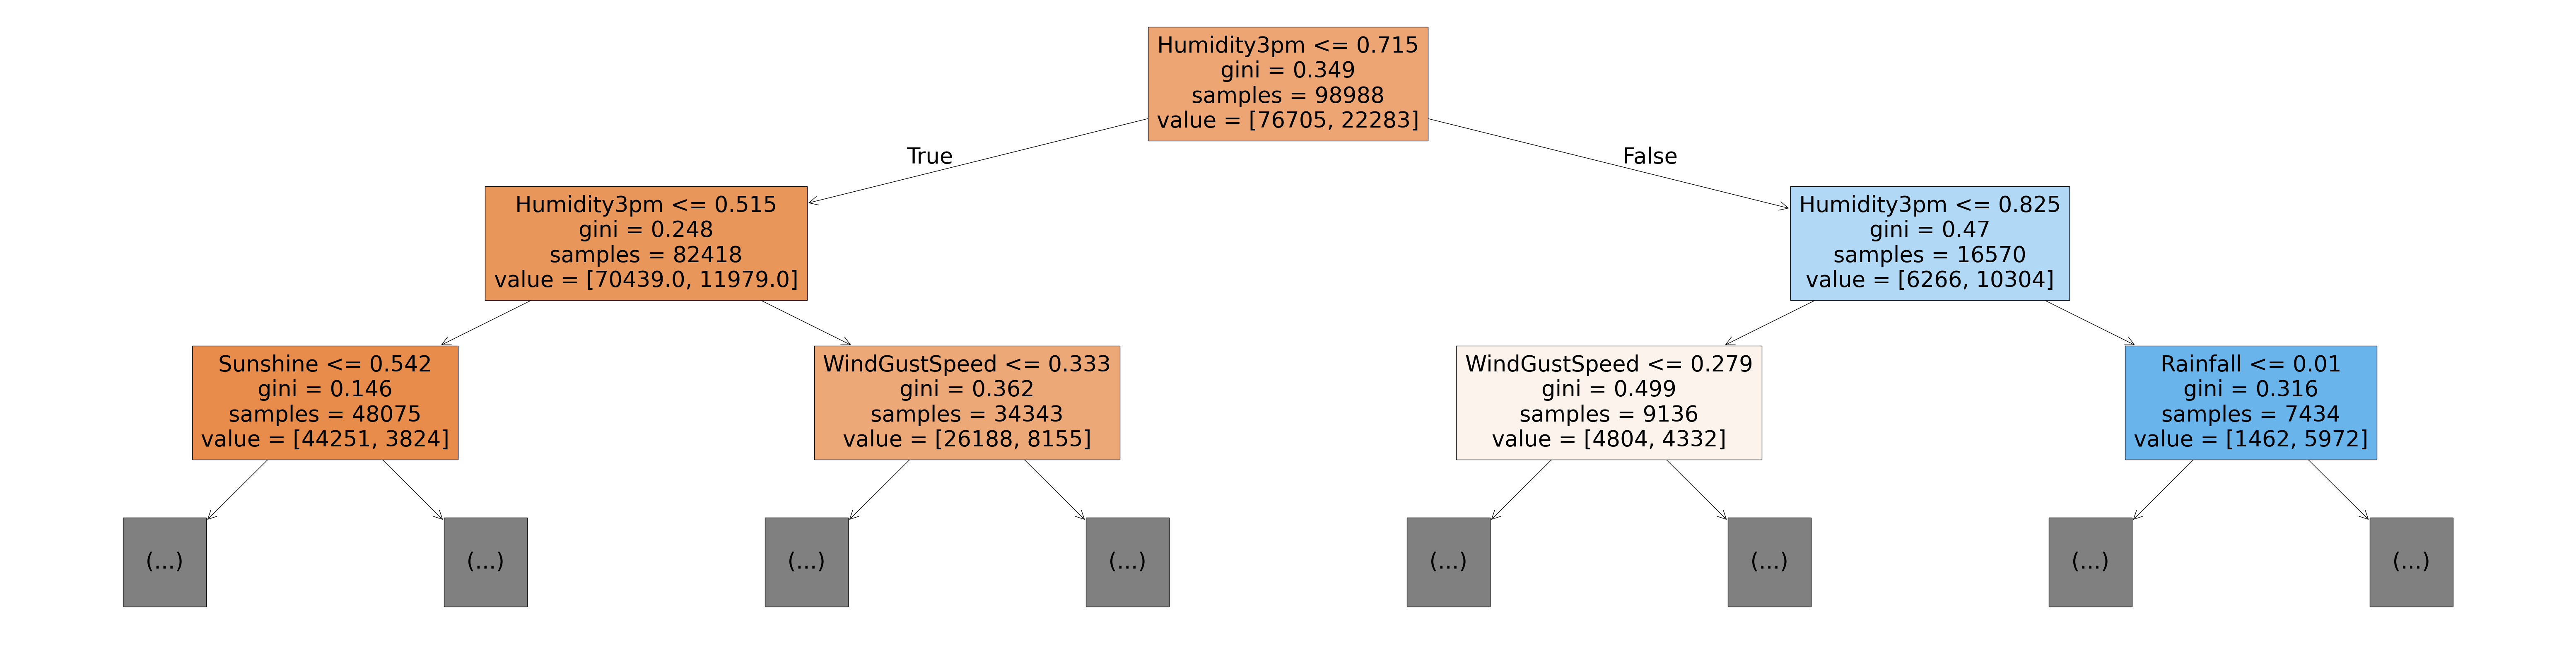

In [ ]:
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(80,20))
plot_tree(tree_model, feature_names=train_X.columns, max_depth=2, filled=True);

In [ ]:
tree_model.feature_importances_

array([3.82034509e-03, 3.32435257e-03, 2.07776780e-02, 2.47498303e-04,
       5.86736471e-02, 9.67126672e-02, 0.00000000e+00, 1.05166843e-03,
       3.64859756e-03, 6.73429008e-01, 1.57075388e-03, 6.86666923e-02,
       0.00000000e+00, 1.36271240e-02, 5.68021507e-03, 2.60089630e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.21717543e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.72011985e-03,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [ ]:
dataframe = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [ ]:
dataframe

,Feature,Importance
9,Humidity3pm,0.673429
5,WindGustSpeed,0.096713
11,Pressure3pm,0.068667
4,Sunshine,0.058674
116,RainToday_No,0.037556
...,...,...
46,Location_Penrith,0.000000
45,Location_PearceRAAF,0.000000
44,Location_Nuriootpa,0.000000
43,Location_NorfolkIsland,0.000000


In [ ]:
model = DecisionTreeClassifier(random_state = 42)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [7]
}
grid_model = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

In [ ]:
grid_model.fit(train_X, train_targets)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [7]}, scoring='accuracy')

In [ ]:
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 7}
0.811431796447448
